# 04 — Final Visualizations & Insight Summary

**Goal:** Produce the final charts that will be used in the Power BI dashboard and the executive summary.

**Input:** `data/processed/sentiment_scored.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/processed/sentiment_scored.csv')
print(f'Loaded: {df.shape}')

Loaded: (25000, 23)


## 1. Word clouds — positive vs negative reviews

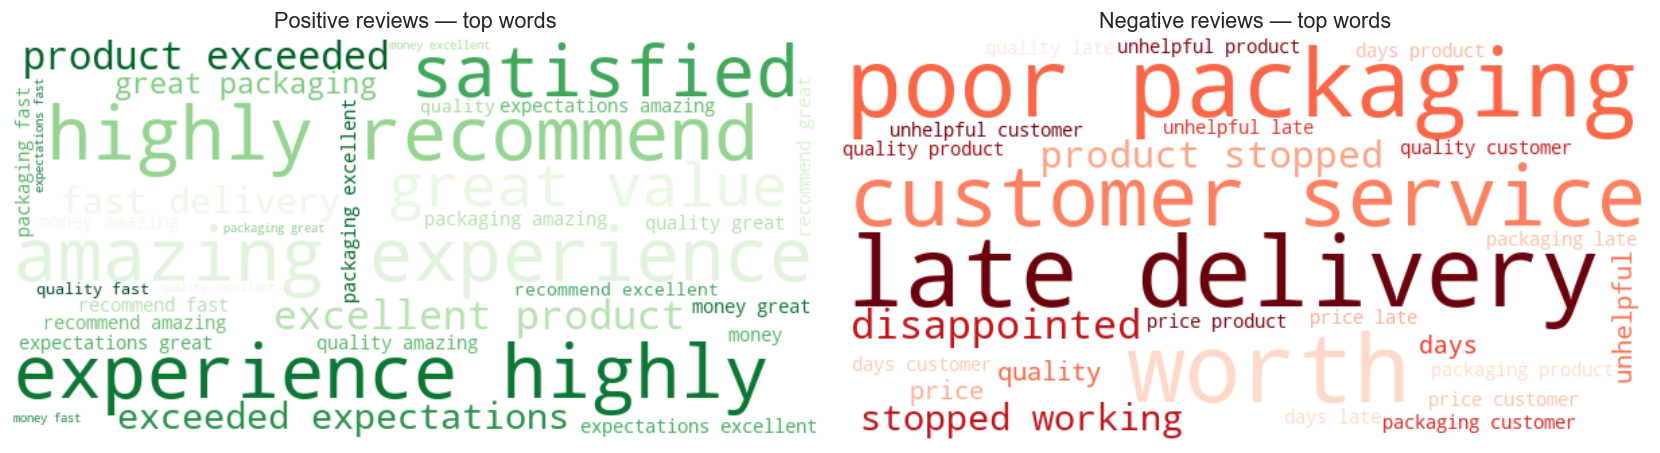

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes, ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['sentiment'] == label]['review_text_clean'].dropna())
    wc = WordCloud(width=600, height=300, background_color='white',
        colormap=color, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()} reviews — top words', fontsize=13)

plt.tight_layout()
plt.savefig('../assets/08_wordclouds.png', bbox_inches='tight')
plt.show()

## 2. Complaint funnel

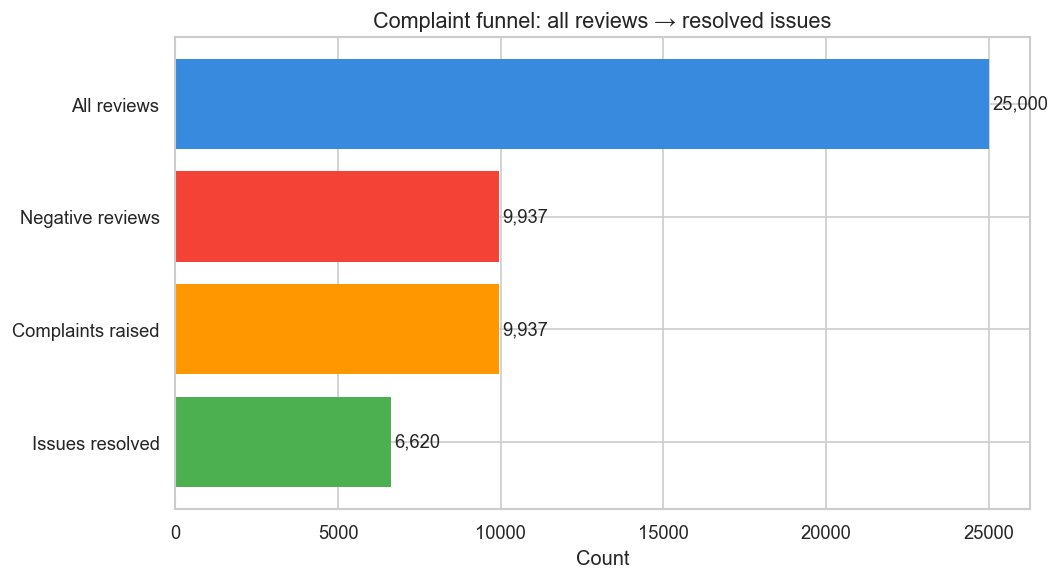

Negative rate:        39.7%
Complaint rate (of neg): 100.0%
Resolution rate:      66.6%


In [4]:
total = len(df)
negative = len(df[df['sentiment'] == 'negative'])
complained = len(df[(df['sentiment'] == 'negative') & (df['complaint_registered'] == 'yes')])
resolved = len(df[(df['sentiment'] == 'negative') & (df['complaint_registered'] == 'yes') & (df['issue_resolved'] == 'yes')])

funnel_data = {
    'All reviews': total,
    'Negative reviews': negative,
    'Complaints raised': complained,
    'Issues resolved': resolved
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(list(funnel_data.keys()), list(funnel_data.values()),
    color=['#378ADD', '#F44336', '#FF9800', '#4CAF50'], edgecolor='none')
for bar, val in zip(bars, funnel_data.values()):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
        f'{val:,}', va='center', fontsize=11)
ax.set_title('Complaint funnel: all reviews → resolved issues', fontsize=13)
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/09_complaint_funnel.png', bbox_inches='tight')
plt.show()

print(f'Negative rate:        {negative/total*100:.1f}%')
print(f'Complaint rate (of neg): {complained/negative*100:.1f}%')
print(f'Resolution rate:      {resolved/complained*100:.1f}%')

## 3. Top & bottom platforms by avg rating

In [5]:
platform_kpis = df.groupby('platform').agg(
    avg_rating=('customer_rating', 'mean'),
    neg_pct=('sentiment', lambda x: (x == 'negative').mean() * 100),
    resolution_rate=('issue_resolved_bin', 'mean'),
    avg_response_hrs=('response_time_hours', 'mean'),
    review_count=('customer_id', 'count')
).round(2).sort_values('avg_rating', ascending=False)

print('Platform KPI Summary:')
print(platform_kpis.to_string())

# Save for Power BI import
platform_kpis.to_csv('../data/processed/platform_kpis.csv')
print('\nSaved platform_kpis.csv')

Platform KPI Summary:
                      avg_rating  neg_pct  resolution_rate  avg_response_hrs  review_count
platform                                                                                  
boat                        3.05    37.55             0.68             35.39          1257
tata cliq                   3.04    38.13             0.67             35.50          1201
ajio                        3.03    38.90             0.67             36.02          1234
amazon                      3.03    39.25             0.67             34.88          1172
reliance digital            3.03    39.33             0.68             36.48          1279
myntra                      3.03    38.44             0.64             37.19          1267
facebook marketplace        3.03    37.97             0.66             36.15          1272
meesho                      3.02    39.68             0.66             35.85          1240
paytm mall                  3.02    39.26             0.64          

## 4. Key insights summary

In [6]:
print('=== KEY INSIGHTS ===')
print()

# Insight 1: Response time threshold
rt_neg = df.groupby('response_time_bucket')['sentiment'].apply(
    lambda x: (x == 'negative').mean() * 100
)
print('Negative sentiment % by response time bucket:')
print(rt_neg)

print()

# Insight 2: Best/worst platform
print(f"Best platform:  {platform_kpis['avg_rating'].idxmax()} ({platform_kpis['avg_rating'].max():.2f}/5)")
print(f"Worst platform: {platform_kpis['avg_rating'].idxmin()} ({platform_kpis['avg_rating'].min():.2f}/5)")

print()

# Insight 3: Resolution impact
resolved_rating = df[df['issue_resolved'] == 'yes']['customer_rating'].mean()
unresolved_rating = df[df['issue_resolved'] == 'no']['customer_rating'].mean()
print(f'Avg rating when resolved:   {resolved_rating:.2f}')
print(f'Avg rating when unresolved: {unresolved_rating:.2f}')
print(f'Delta: +{resolved_rating - unresolved_rating:.2f} stars from resolving issues')

=== KEY INSIGHTS ===

Negative sentiment % by response time bucket:
response_time_bucket
12-24h    39.239905
24-48h    40.511122
<12h      39.079380
>48h      39.566832
Name: sentiment, dtype: float64

Best platform:  boat (3.05/5)
Worst platform: flipkart (2.94/5)

Avg rating when resolved:   3.00
Avg rating when unresolved: 3.01
Delta: +-0.01 stars from resolving issues
